In [1]:
import os
# 禁止 JAX 预占所有显存，用多少拿多少
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from pennylane.fermi import FermiSentence, from_string
import pennylane as qml
from pennylane import numpy as np
import time
qml.about()
import catalyst

Name: pennylane
Version: 0.43.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
Author-email: 
License-Expression: Apache-2.0
Location: /home/lzs/.conda/envs/lzsgpu/lib/python3.12/site-packages
Requires: appdirs, autograd, autoray, cachetools, diastatic-malt, networkx, numpy, packaging, pennylane-lightning, requests, rustworkx, scipy, tomlkit, typing_extensions
Required-by: pennylane_catalyst, pennylane_lightning, pennylane_lightning_gpu

Platform info:           Linux-6.11.0-26-generic-x86_64-with-glibc2.39
Python version:          3.12.12
Numpy version:           2.3.4
Scipy version:           1.16.2
JAX version:             0.6.2
Installed devices:
- default.clifford (pennylane-0.43.1)
- default.gaussian (pennylane-0.43.1)
- default.mixed (pennylane-0.43.1)
- default.qubit (pennylane-0.43.1)
- default.qutrit (pennylane-0.43.1)


In [2]:
import os
# 禁止 JAX 预占所有显存，用多少拿多少
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from pennylane.fermi import FermiSentence, from_string
import pennylane as qml
from pennylane import numpy as np
import time
qml.about()
import catalyst

Name: pennylane
Version: 0.43.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
Author-email: 
License-Expression: Apache-2.0
Location: /home/lzs/.conda/envs/lzsgpu/lib/python3.12/site-packages
Requires: appdirs, autograd, autoray, cachetools, diastatic-malt, networkx, numpy, packaging, pennylane-lightning, requests, rustworkx, scipy, tomlkit, typing_extensions
Required-by: pennylane_catalyst, pennylane_lightning, pennylane_lightning_gpu

Platform info:           Linux-6.11.0-26-generic-x86_64-with-glibc2.39
Python version:          3.12.12
Numpy version:           2.3.4
Scipy version:           1.16.2
JAX version:             0.6.2
Installed devices:
- default.clifford (pennylane-0.43.1)
- default.gaussian (pennylane-0.43.1)
- default.mixed (pennylane-0.43.1)
- default.qubit (pennylane-0.43.1)
- default.qutrit (pennylane-0.43.1)


In [3]:
import jax
print('✅ JAX version:', jax.devices())
import jax
print('✅ JAX version:', jax.__version__)
print('✅ Devices:', jax.devices())
if any(d.platform == 'gpu' for d in jax.devices()):
    print('🎉 GPU is working!')
else:
    print('⚠️ No GPU detected')

✅ JAX version: [CudaDevice(id=0)]
✅ JAX version: 0.6.2
✅ Devices: [CudaDevice(id=0)]
🎉 GPU is working!


In [4]:
# 1. 导入必要库（和之前一致，必须用 scipy.sparse）
import scipy.sparse as sp

# 2. 直接写文件名（相对路径，同目录下无需加任何路径前缀）
matrix_file = "L=4 N=3.npz"  # 重点：只写文件名，不用加 /Users/... 之类的路径

# 3. 加载矩阵（一行搞定，自动恢复 CSR 格式）
H_3 = sp.load_npz(matrix_file)

# 4. 验证加载成功（可选，快速确认没出错）
print("✅ 矩阵调用成功！")
print(f"矩阵格式：{H_3.format}")  # 输出 'csr'（和保存时一致）
print(f"矩阵形状：{H_3.shape}")    # 输出原矩阵的行数×列数
print(f"非零元素个数：{H_3.nnz}")  # 输出非零元素数量

from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
H= H_3.toarray()
# 计算模最小的特征值（注意可能为复数）
min_eigval = eigsh(H, k=3, which='SA', return_eigenvectors=True,)

min =  eigh( H,eigvals_only=True)[0]
print("最小特征值:", min_eigval[0])
print(min)

✅ 矩阵调用成功！
矩阵格式：csr
矩阵形状：(54, 54)
非零元素个数：596
最小特征值: [-17.68122644  19.89038667  78.03820097]
-17.681226438773784


In [5]:
import pennylane as qml
import jax
import jax.numpy as jnp
import numpy as np  # 用于预处理，非计算图部分
import time
import optax  # JAX 的标准优化库 (需要 pip install optax)

from catalyst import qjit, grad

# =================== 0. 辅助函数 (保持不变) ===================
def get_Hami(H):
    # 安全地将 H 转换为无梯度的 NumPy 数组
    if hasattr(H, 'toarray'):
        H = H.toarray()
    if hasattr(H, 'detach'):
        H = H.detach().cpu().numpy()
    elif hasattr(H, 'numpy'):
        H = H.numpy()
    else:
        H = np.asarray(H)

    H_dense = np.array(H, copy=True)
    d = H_dense.shape[0]
    Nq = int(np.ceil(np.log2(d)))
    l = 2 ** Nq

    Hami = np.zeros((l, l), dtype=H_dense.dtype)
    np.fill_diagonal(Hami, 1000)
    Hami[:d, :d] = H_dense

    return Hami, Nq

H_sy,Nq = get_Hami(H)

print(Nq)

6


In [6]:
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np

H_sy,n_qubits = get_Hami(H)
H_sy = coo_matrix(H_sy)
# ---------- 1. 生成 Gray 码 ----------
def gray_code(n: int) -> list[str]:
    """返回 n-bit Gray 码列表，顺序对应 0..2^n-1"""
    if n == 1:
        return ["0", "1"]
    lower = gray_code(n - 1)
    return ["0" + x for x in lower] + ["1" + x for x in reversed(lower)]

gray_basis   = gray_code(Nq)                        # len == 2**Nq
gray2natural = np.array([int(g, 2) for g in gray_basis], dtype=np.int64)

# ---------- 2. 构造 Gray-ordered 哈密顿量 ----------

rows, cols = H_sy.nonzero()          # 默认是 int32/uint32
data       = H_sy.data

# 关键修复：先把索引数组变成 int64，再做高级索引
rows = rows.astype(np.int64, copy=False)
cols = cols.astype(np.int64, copy=False)

new_rows = gray2natural[rows]
new_cols = gray2natural[cols]

print('data  len:', len(data))
print('rows  len:', len(new_rows))
print('cols  len:', len(new_cols))

# 现在三者长度一致，且索引不会溢出
H_gray = coo_matrix((data, (new_rows, new_cols)),
                    shape=(2**Nq, 2**Nq)).tocsr()

H_gray = H_gray.toarray()








data  len: 606
rows  len: 606
cols  len: 606


depth: 17


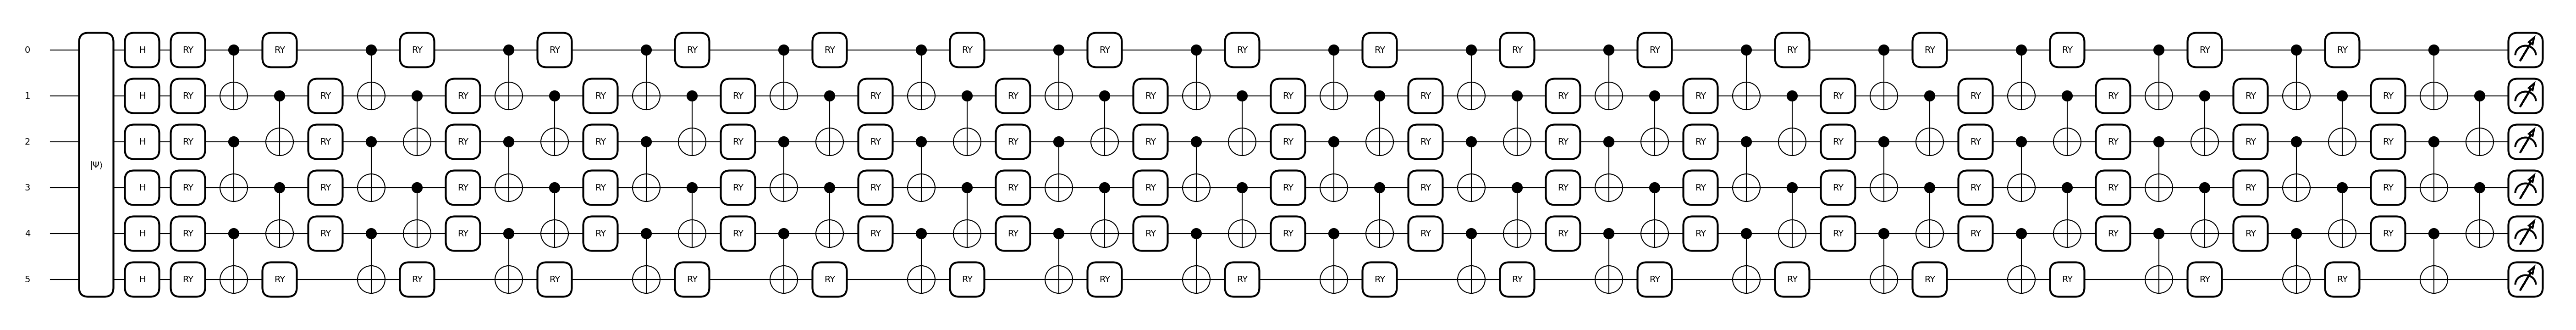

资源统计结果：
{'resources': Resources(num_wires=6, num_gates=193, gate_types=defaultdict(<class 'int'>, {'CNOT': 85, 'RY': 102, 'Hadamard': 6}), gate_sizes=defaultdict(<class 'int'>, {2: 85, 1: 108}), depth=52, shots=Shots(total_shots=None, shot_vector=())), 'num_device_wires': 6, 'device_name': 'lightning.gpu', 'level': 'device', 'gradient_options': {}, 'interface': 'auto', 'diff_method': 'best'}
深度 (Depth): 52
门总数 (Total Gates): 193
门类型统计: defaultdict(<class 'int'>, {'CNOT': 85, 'RY': 102, 'Hadamard': 6})


In [15]:
from jax import numpy as jnp
import matplotlib.pyplot as plt
import math  # 必须先导入math模块，ceil是math的内置函数

depth = math.ceil(2**Nq/Nq)+Nq

print('depth:', depth)
steps =1000
lr = 0.05
seed = 42

H,n_qubits = get_Hami(H)
H = jnp.array(H_gray, dtype=jnp.complex128)

H_hermitian = qml.Hermitian(H, wires=range(n_qubits))

hf = np.zeros(n_qubits)
# 使用 lightning.gpu 设备
dev = qml.device("lightning.gpu", wires=n_qubits)

@qml.qjit
@qml.qnode(dev)
def cost(params):

    qml.BasisState(hf, wires=range(n_qubits))
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for d in range(depth):
        for i in range(n_qubits):
            qml.RY(params[d*n_qubits+i], wires=i)

        for i in range(0, n_qubits - 1, 2):  # 步长2，从0开始
            qml.CNOT(wires=[i, i + 1])

        qml.CNOT(wires=[n_qubits-1, 0])

        for i in range(1, n_qubits - 1, 2):  # 步长2，从1开始
            qml.CNOT(wires=[i, i + 1])


    return qml.expval(H_hermitian)

n = depth * n_qubits
init_params = jnp.zeros(n)

# 生成电路可视化对象
fig, ax = qml.draw_mpl(cost)(init_params)
# 显示绘制的电路
plt.show()

n = depth * n_qubits
init_params = jnp.zeros(n)

cost(init_params)

# 使用 qml.specs 获取统计信息
# level="device" 意味着统计的是设备实际执行的门（即经过编译/分解后的）
specs_func = qml.specs(cost, compute_depth=True, level="device")

# 运行函数以获取结果（需要传入电路参数）
info = specs_func(init_params)

print("资源统计结果：")
print(info)
print(f"深度 (Depth): {info['resources'].depth}")
print(f"门总数 (Total Gates): {info['resources'].num_gates}")
print(f"门类型统计: {info['resources'].gate_types}")

In [22]:
import catalyst
import optax
import numpy as np
import gc
import jax
import jax.numpy as jnp
import os
import signal
import sys
from jax import devices, device_put

# 定义目标能量和收敛容忍度
target_energy = min
tolerance = 1e-6
steps = 5000
schedule = optax.exponential_decay(
    init_value=0.02,
    transition_steps=300,
    decay_rate=0.9
)
# 初始化优化器
opt = optax.adam(learning_rate=schedule)
opt_state = opt.init(init_params)
params = init_params

# 创建数组存储训练过程数据
step_history = []
energy_history = []

@qml.qjit
def update_step(i, params, opt_state):
    """Perform a single gradient update step"""
    energy, grads = catalyst.value_and_grad(cost)(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return (params, opt_state, energy)

# 训练循环
converged = False
for i in range(steps):
    params, opt_state, energy = update_step(i, params, opt_state)

    # 保存步骤和能量值
    step_history.append(i)
    energy_history.append(float(energy))

    if i % 50 == 0:
        print(f"Step = {i},  Energy = {energy:.8f} Ha")

    # 检查收敛条件
    if abs(energy - target_energy) < tolerance:
        print(f"Converged at step {i} with energy {energy:.8f} Ha")
        converged = True
        break

# 将列表转换为NumPy数组
step_array = np.array(step_history)
energy_array = np.array(energy_history)

print(f"Training completed. Total steps: {len(step_array)}")
print(f"Final energy: {energy_array[-1]:.8f} Ha")

print(min)


# 如果没有重启，打印完成信息
print("\nMemory release procedure completed")
print(f"Step array shape: {step_array.shape}, Energy array shape: {energy_array.shape}")

Step = 0,  Energy = 195.52299888 Ha
Step = 50,  Energy = -11.03268934 Ha
Step = 100,  Energy = -16.15532662 Ha
Step = 150,  Energy = -17.30832712 Ha
Step = 200,  Energy = -17.61551828 Ha
Step = 250,  Energy = -17.67261716 Ha
Step = 300,  Energy = -17.67990285 Ha
Step = 350,  Energy = -17.68089490 Ha
Step = 400,  Energy = -17.68112786 Ha
Step = 450,  Energy = -17.68119765 Ha
Step = 500,  Energy = -17.68121851 Ha
Step = 550,  Energy = -17.68122439 Ha
Converged at step 576 with energy -17.68122545 Ha
Training completed. Total steps: 577
Final energy: -17.68122545 Ha
-17.681226438773784

Memory release procedure completed
Step array shape: (577,), Energy array shape: (577,)


In [11]:
# 保存数组到/home/lzs/目录，文件名为energy_data.npy（可自定义文件名）
save_path = '/home/lzs/energy_3_4.npy'
np.save(save_path, energy_array)
1303
print(f"数组已成功保存到：{save_path}")


数组已成功保存到：/home/lzs/energy_3_4.npy


x轴长度：577，y轴长度：577
x轴数据：[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240

/tmp/ipykernel_1239437/3955325276.py:31: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1239437/3955325276.py:31: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1239437/3955325276.py:31: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1239437/3955325276.py:31: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1239437/3955325276.py:31: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1239437/3955325276.py:31: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1239437/3955325276.py:31: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOG

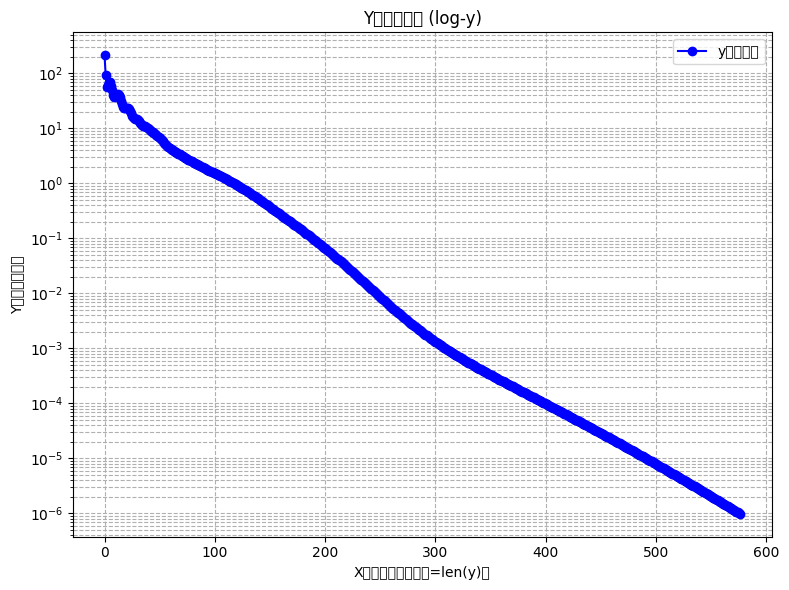

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 1. 定义y数组（替换为你的真实数据） ----------------------
# 示例y数组：指数增长数据（适合log图展示）
y = energy_array+17.681226438773784
# 自动生成x轴数据：长度与y一致，取值为0,1,2,...,len(y)-1
# 如果需要x从1开始，可改为 x = np.arange(1, len(y)+1)
x = np.arange(len(y))

# 打印验证：查看x和y的长度是否一致
print(f"x轴长度：{len(x)}，y轴长度：{len(y)}")
print(f"x轴数据：{x}")
print(f"y轴数据：{y}")

# ---------------------- 2. 绘制log图（适配自动生成的x） ----------------------
plt.figure(figsize=(8, 6))

# 子图1：仅y轴对数坐标（最常用）

plt.plot(x, y, color='blue', marker='o', label='y数组数据')  # 加marker更易看数据点
plt.yscale('log')  # y轴设为对数坐标
plt.title('Y轴对数坐标 (log-y)')
plt.xlabel('X（自动生成，长度=len(y)）')
plt.ylabel('Y（对数坐标）')
plt.grid(True, which="both", ls="--")
plt.legend()



plt.tight_layout()
plt.show()

In [9]:
print("这行代码会正常执行")
print("执行完上面这句，下面会触发停止")

gc.collect()
# 核心停止指令：执行到这一行，程序立刻终止
raise SystemExit

# 👇 这行及之后的所有代码，永远不会执行！！！
print("这行代码不会被打印，因为上面已经停止了")
print("后面的所有逻辑都失效")

这行代码会正常执行
执行完上面这句，下面会触发停止


SystemExit: 

/home/lzs/.conda/envs/lzsgpu/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [8]:

import catalyst
import optax
steps = 5000
lr = 0.001
#opt = optax.adam(0.001)


opt = optax.adabelief(learning_rate=0.01)

opt_state = opt.init(init_params)

params = init_params


@qml.qjit
def update_step(i, params, opt_state):
    """Perform a single gradient update step"""
    energy, grads = catalyst.value_and_grad(cost)(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    # catalyst.debug.print("Step = {i},  Energy = {energy:.8f} Ha", i=i, energy=energy)
    return (params, opt_state, energy)



for i in range(steps):
    params, opt_state,energy = update_step(i, params, opt_state)
    if i % 1 == 0:
        print(f"Step = {i},  Energy = {energy:.8f} Ha")

# -8.48179737

Step = 0,  Energy = 4.89900142 Ha
Step = 1,  Energy = 0.22279022 Ha
Step = 2,  Energy = -4.04154169 Ha
Step = 3,  Energy = -7.79385809 Ha
Step = 4,  Energy = -10.95847722 Ha
Step = 5,  Energy = -13.51487236 Ha
Step = 6,  Energy = -15.52052911 Ha
Step = 7,  Energy = -17.09752367 Ha
Step = 8,  Energy = -18.38243852 Ha
Step = 9,  Energy = -19.48006565 Ha
Step = 10,  Energy = -20.44955395 Ha
Step = 11,  Energy = -21.31430949 Ha
Step = 12,  Energy = -22.07728126 Ha
Step = 13,  Energy = -22.73262363 Ha
Step = 14,  Energy = -23.27253150 Ha
Step = 15,  Energy = -23.69076749 Ha
Step = 16,  Energy = -23.98460214 Ha
Step = 17,  Energy = -24.15627819 Ha
Step = 18,  Energy = -24.21432463 Ha
Step = 19,  Energy = -24.17437487 Ha
Step = 20,  Energy = -24.05884169 Ha
Step = 21,  Energy = -23.89504063 Ha
Step = 22,  Energy = -23.71200886 Ha
Step = 23,  Energy = -23.53687857 Ha
Step = 24,  Energy = -23.39179863 Ha
Step = 25,  Energy = -23.29203467 Ha
Step = 26,  Energy = -23.24536169 Ha
Step = 27,  Energ

RuntimeError: KeyboardInterrupt (SIGINT)

In [ ]:
import concurrent.futures
import copy

def run_optimizer(name, opt, init_params, steps):
    # 注意：必须在函数内部定义 qjit，避免跨线程共享编译对象
    @qml.qjit
    def update_step(i, params, opt_state):
        energy, grads = catalyst.value_and_grad(cost)(params)
        updates, opt_state = opt.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state, energy

    params = copy.deepcopy(init_params)
    opt_state = opt.init(params)
    history = []

    for i in range(steps):
        params, opt_state, energy = update_step(i, params, opt_state)
        if i % 50 == 0:
            print(f"[{name}] Step = {i}, Energy = {energy:.8f} Ha")
            history.append((i, float(energy)))
    return name, history

# 主程序
optimizers = {
    "adam": optax.adam(0.001),
    #"rmsprop": optax.rmsprop(0.02),
    #"sgd": optax.sgd(0.05),
}

with concurrent.futures.ThreadPoolExecutor(max_workers=len(optimizers)) as executor:
    futures = [
        executor.submit(run_optimizer, name, opt, init_params, steps)
        for name, opt in optimizers.items()
    ]
    results = dict(f.result() for f in concurrent.futures.as_completed(futures))

In [ ]:
@qml.qjit
def optimization(params):
    opt_state = opt.init(params)
    (params, opt_state) = qml.for_loop(0, steps, 1)(update_step)(params, opt_state)
    return params
final_params = optimization(init_params)

# print(f"Final angle parameters: {final_params}")

In [ ]:


# =================== 1. 准备数据 ===================


# 获取处理后的 Hamiltonian
Hami_np, n_qubits = get_Hami(H)

# !!! 关键点：将 NumPy 数组转换为 JAX 数组，并移动到 GPU (如果可用) !!!
Hami = jnp.array(Hami_np)
print(f"Qubits: {n_qubits}")

# =================== 2. 超参数与设备 ===================
depth = 100
steps = 2000 # JAX 很快，可以跑更多步，或者演示用少一点
lr = 0.05
seed = 42

# 使用 lightning.gpu 设备
dev = qml.device("lightning.gpu", wires=n_qubits)

# =================== 3. 定义电路 (QNode) ===================
# 注意：我们这里不直接装饰 @qjit，而是稍后在优化步中一起编译
@qml.qnode(dev)
def circuit_node(params, hamiltonian_matrix):
    params = params.reshape((depth, n_qubits))

    for d in range(depth):
        for i in range(n_qubits):
            qml.RY(params[d, i], wires=i)

        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

    # 使用 Hermitian 算符
    return qml.expval(qml.Hermitian(hamiltonian_matrix, wires=range(n_qubits)))

# =================== 4. 定义优化步骤 (JIT 编译核心) ===================

# 初始化优化器 (Optax)
optimizer = optax.adam(learning_rate=lr)

# 定义损失函数
def cost_fn(params, hamiltonian_matrix):
    return circuit_node(params, hamiltonian_matrix)

# 定义单步更新函数，并加上 @qjit 编译整个流程
# 这会将 梯度计算 + 参数更新 + 电路执行 全部编译成机器码
@qjit
def update_step(params, opt_state, hamiltonian_matrix):
    # 1. 计算损失和梯度
    loss, grads = jax.value_and_grad(cost_fn)(params, hamiltonian_matrix)

    # 2. 计算参数更新量
    updates, new_opt_state = optimizer.update(grads, opt_state)

    # 3. 应用更新
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss

# =================== 5. 训练循环 ===================
print(f"\n>>> 开始 JAX+Catalyst 优化（共 {steps} 步）")

# 初始化参数 (使用 JAX 的随机键)
key = jax.random.PRNGKey(seed)
init_params = jax.random.uniform(key, shape=(depth * n_qubits,), minval=0, maxval=2*jnp.pi)

# 初始化优化器状态
opt_state = optimizer.init(init_params)

params = init_params

# 计时开始
# 注意：第一次运行包含编译时间 (Compile time)
tic = time.time()

for step in range(steps + 1):
    params, opt_state, loss = update_step(params, opt_state, Hami)

    # 将 loss 转回 CPU 打印 (这会触发同步，不要每一步都打印，否则会拖慢速度)
    if step % 50 == 0:
        # float(loss) 会强制同步数据
        print(f"  step {step:3d}  energy = {float(loss):.8f}")

toc = time.time()

print(f"Final Energy = {loss:.8f}")
print(f"Total Time   = {toc-tic:.2f}s (含编译时间)")

In [ ]:
import pennylane as qml
import time
from pennylane import numpy as np

# ===================  超参数  ===================
n_qubits = 9
depth    = 100
steps    = 10000
seed     = 42
np.random.seed(seed)



# ===================  设备  ===================
dev = qml.device("lightning.gpu", wires=n_qubits)

# ===================  Ansatz  ===================
def ansatz(params):
    params = params.reshape((depth, n_qubits))
    for d in range(depth):
        for i in range(n_qubits):

            qml.RY(params[d, i], wires=i)

        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def energy_fn(params):
    ansatz(params)
    return qml.expval(qml.Hermitian(Hami, wires=range(n_qubits)) )

# ===================  优化器列表  ===================
optimizers = {
    "Adam"     : (qml.optimize.AdamOptimizer, 0.05, {}),

}

# ===================  训练循环  ===================
results = {}
for name, (OptClass, lr, kw) in optimizers.items():
    print(f"\n>>> 开始 {name} 优化（共 {steps} 步）")
    params = np.random.uniform(0, 2*np.pi, (depth,  n_qubits), requires_grad=True)
    opt    = OptClass(lr, **kw) if lr is not None else OptClass(**kw)

    tic = time.time()
    for step in range(steps + 1):
        params, loss = opt.step_and_cost(energy_fn, params)
        if step % 50 == 0:
            print(f"  step {step:3d}  energy = {loss:.8f}")
    toc = time.time()

    final_e = energy_fn(params)
    results[name] = final_e
    print(f"{name:10s} 最终能量 = {final_e:.8f}  耗时 = {toc-tic:.2f}s")

# ===================  汇总  ===================
print("\n" + "="*50)
for name, e in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name:10s}  {e:.8f}")


In [ ]:
import pennylane as qml
import time
from pennylane import numpy as np
from scipy.optimize import minimize

# ===================  超参数  ===================
n_qubits = 9
depth    = 30
steps    = 1000          # 仅用于 PennyLane 优化器
seed     = 42
np.random.seed(seed)

# ===================  设备  ===================
dev = qml.device("lightning.gpu", wires=n_qubits)   # 没 GPU 就换 lightning.qubit

# ===================  哈密顿量  ===================


# ===================  Ansatz  ===================
def ansatz(params):
    params = params.reshape((depth, n_qubits))
    for d in range(depth):
        for i in range(n_qubits):
            qml.RY(params[d, i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def energy_fn(params):
    ansatz(params)
    return qml.expval(qml.Hermitian(Hami, wires=range(n_qubits)))

# ---------- 扁平接口，供 scipy 使用 ----------
def flat_energy(p_flat):
    return float(energy_fn(p_flat))

def flat_grad(p_flat):
    return qml.grad(energy_fn)(p_flat)

# ===================  优化器列表  ===================
# 对 PennyLane 优化器用 step_and_cost；对 SLSQP 用 minimize
optimizers = {
    #"Adam" : (qml.optimize.AdamOptimizer, 0.05, {}),
    #"SPSA" : (qml.optimize.SPSAOptimizer, 0.02, {"c": 0.3}),
    "SLSQP": None,   # 特殊处理
}

# ===================  训练循环  ===================
results = {}
for name in optimizers:
    print(f"\n>>> 开始 {name} 优化")
    x0 = np.zeros(depth*n_qubits, requires_grad=True)

    tic = time.time()
    if name == "SLSQP":
        res = minimize(flat_energy, x0=x0, method="SLSQP",
                       options={"maxiter": 1000, "ftol": 1e-8})
        final_e, params = res.fun, res.x
    else:
        OptClass, lr, kw = optimizers[name]
        opt = OptClass(lr, **kw)
        for step in range(steps + 1):
            x0, loss = opt.step_and_cost(energy_fn, x0)
            if step % 100 == 0:
                print(f"  step {step:4d}  energy = {loss:.8f}")
        final_e = energy_fn(x0)
        params = x0
    toc = time.time()

    results[name] = final_e
    print(f"{name:10s} 最终能量 = {final_e:.8f}  耗时 = {toc-tic:.2f}s")

# ===================  汇总  ===================
print("\n" + "="*50)
for name, e in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name:10s}  {e:.8f}")


In [ ]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer,RotosolveOptimizer

##############################
# 1. 问题参数：比特数、HEA 深度
##############################
n_qubits = 9
N = n_qubits             # 任意 N 比特
depth = 20         # HEA 层数
steps = 400        # VQE 迭代步数
lr = 0.05          # Adam 学习率

##############################
# 2. 定义哈密顿量（Transverse-Field Ising）
##############################
         # hx

##############################
# 3. 构造 Hardware-Efficient Ansatz
#    每层：单比特旋转 RX-RY-RX + CNOT 纠缠
##############################
def hea_layer(params):
    """单个 HEA 层：params 形状 (3, N)"""
    for i in range(N):
        qml.RX(params[0, i], wires=i)
        qml.RY(params[1, i], wires=i)
        qml.RX(params[2, i], wires=i)
    # 线性邻接 CNOT 纠缠
    for i in range(N - 1):
        qml.CNOT(wires=[i, i + 1])

def ansatz(params):
    """depth 层 HEA"""
    params = params.reshape((depth, 3, N))
    for d in range(depth):
        hea_layer(params[d])

##############################
# 4. 定义 QNode：返回能量期望值
##############################
dev = qml.device("lightning.gpu", wires=N)

@qml.qnode(dev, interface="autograd")
def energy_fn(params):
    ansatz(params)
    return qml.expval(qml.Hermitian(Hami, wires=range(n_qubits)))

##############################
# 5. 初始化参数并运行 VQE
##############################
params = np.zeros((depth, 3, N), requires_grad=True)

opt = qml.optimize.NesterovMomentumOptimizer(0.01, 0.9)

print("开始 VQE 优化...")
for step in range(steps + 1):
    params, loss = opt.step_and_cost(energy_fn, params)
    if step % 10 == 0:
        print(f"Step {step:3d} | energy = {loss:.8f}")

print("\n最终基态能量估计:", energy_fn(params))

##############################
# 6. 可选：打印最终线路
##############################
# 在 PennyLane 0.43 里，只要这样即可：
# print(qml.draw(energy_fn)(params))




In [ ]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer, RotosolveOptimizer

##############################
# 1. 问题参数：比特数、HEA 深度
##############################
n_qubits = 12
N = n_qubits             # 任意 N 比特
depth = 20               # HEA 层数
steps = 400              # VQE 迭代步数
lr = 0.05                # Adam 学习率（Rotosolve 不用）

##############################
# 2. 定义哈密顿量（Transverse-Field Ising）
##############################
# 这里你原来怎么定义 Hami 就怎么来
# Hami = ...

##############################
# 3. 构造 Hardware-Efficient Ansatz
##############################
def hea_layer(params):
    """单个 HEA 层：params 形状 (3, N)"""
    for i in range(N):
        qml.RX(params[0, i], wires=i)
        qml.RY(params[1, i], wires=i)
        qml.RX(params[2, i], wires=i)
    # 线性邻接 CNOT 纠缠
    for i in range(N - 1):
        qml.CNOT(wires=[i, i + 1])

def ansatz(params):
    """depth 层 HEA"""
    params = params.reshape((depth, 3, N))
    for d in range(depth):
        hea_layer(params[d])

##############################
# 4. 定义 QNode：返回能量期望值
##############################
dev = qml.device("lightning.gpu", wires=N)

@qml.qnode(dev, interface="autograd")
def energy_fn(params):
    ansatz(params)
    return qml.expval(qml.Hermitian(Hami, wires=range(n_qubits)))

##############################
# 5. 初始化参数
##############################
params = np.random.uniform(0, 2 * np.pi, size=(depth, 3, N), requires_grad=True)

##############################
# 5.1 为 Rotosolve 设置频率信息（关键！！）
##############################
# params 的名字就是 energy_fn 的参数名 "params"
# 形状 (depth, 3, N)，每个标量参数都只在一个 RX/RY/RX 旋转里，
# 对应的频率个数 = 1
nums_frequency = {
    "params": { (d, k, i): 1
                for d in range(depth)
                for k in range(3)
                for i in range(N) }
}

##############################
# 5.2 选择 Rotosolve 优化器
##############################
opt = qml.RotosolveOptimizer()

print("开始 VQE 优化（Rotosolve）...")
for step in range(steps + 1):
    params, loss = opt.step_and_cost(
        energy_fn,
        params,
        nums_frequency=nums_frequency,   # ⭐ 一定要传这一项
    )
    if step % 10 == 0:
        print(f"Step {step:3d} | energy = {loss:.8f}")

print("\n最终基态能量估计:", energy_fn(params))

##############################
# 6. 可选：打印最终线路
##############################
# print(qml.draw(energy_fn)(params))
